**************
early - T-test between spatial and spatiotemporal models
TtestResult(statistic=np.float64(0.2972495857724849), pvalue=np.float64(0.7706408357509057), df=np.int64(14))
spatial mean  0.35 0.06
spatiotemporal mean  0.34 0.06
**************
late - T-test between spatial and spatiotemporal models
TtestResult(statistic=np.float64(-3.1487968060172586), pvalue=np.float64(0.00710861960835317), df=np.int64(14))
spatial mean  0.28 0.04
spatiotemporal mean  0.3 0.05


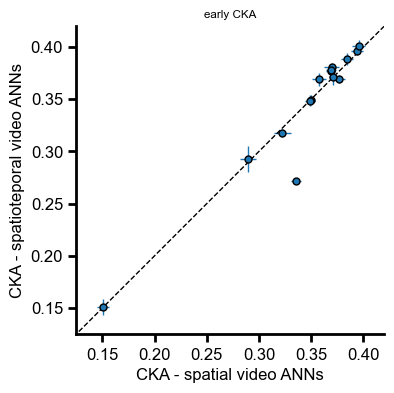

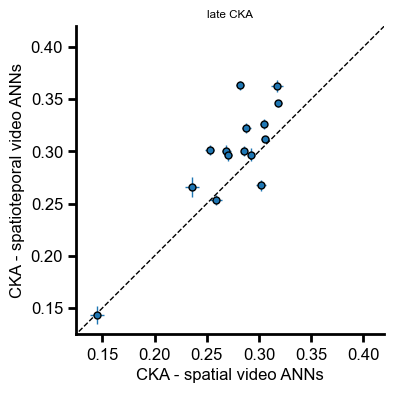

In [2]:
import sys
sys.path.append('../')

import os 
import shutil
import numpy as np
import h5py
import matplotlib.pyplot as plt
from utils.plot_utils import journal_figure_pdf, journal_figure
import scienceplots
import scipy.stats as stats

plt.style.use(['nature'])

scores_path = '../../scores/figure5'

static_models = {
    "images_moving1_c2d_r50-blocks.4.res_blocks.5.activation_repeated-frame_features_srp-rgb2afv_1000_10.h5" : ['f', 'tab:gray', 'C2D'], 
    "images_moving1_i3d_r50-blocks.5.res_blocks.2.activation_repeated-frame_features_srp-rgb2afv_1000_10.h5" : ['f', 'tab:gray', 'I3D'], 
    "images_moving1_x3d_xs-blocks.4.res_blocks.6.activation_repeated-frame_features_srp-rgb2afv_1000_10.h5" : ['f', 'tab:gray', 'X3D'], 
    "images_moving1_sam2.1_hiera_b+-256-memory_attention-2_repeated-frame_features_srp_1000_10.h5" : ['f', 'tab:gray', 'SAM2'], 
    "images_moving1_slow_r50_ssv2-blocks.4.res_blocks.2.activation_repeated-frame_features_srp-rgb2afv_1000_10.h5" : ['f', 'tab:gray', 'SlowR50-ssv2'], 
    "images_moving1_slow_r50-blocks.4.res_blocks.2.activation_repeated-frame_features_srp-rgb2afv_1000_10.h5" : ['f', 'tab:gray', 'SlowR50'], 
    "images_moving1_timesformer_ssv2-timesformer.encoder.layer.8_repeated-frame_features_srp-rgb2afv_1000_10.h5" : ['f', 'tab:gray', 'TimesFormer-ssv2'], 
    "images_moving1_timesformer-timesformer.encoder.layer.11_repeated-frame_features_srp-rgb2afv_1000_10.h5" : ['f', 'tab:gray', 'TimesFormer'], 
    "images_moving1_videomamba_ssv2-layers.10.mixer_repeated-frame_features_srp-rgb2afv_1000_10.h5"  : ['f', 'tab:gray', 'VideoMamba-ssv2'], 
    "images_moving1_videomamba-layers.10.mixer_repeated-frame_features_srp-rgb2afv_1000_10.h5" : ['f', 'tab:gray', 'VideoMamba'], 
    "images_moving1_videomae-videomae.encoder.layer.2_repeated-frame_features_srp_1000_10.h5" : ['f', 'tab:gray', 'VideoMAE'],
    "images_moving1_matnet_fusion_type_gated-layer4,sensor_fusion_e-of_repeated-frame_features_srp_1000_10.h5" : ['f', 'tab:brown', 'MatNet'],
    "images_moving1_twostream_deeplabv3plus_resnet101_davis-layer4,sensor_fusion_e-of_repeated-frame_features_srp_1000_10.h5" : ['f', 'tab:gray', 'FusionSeg'],
    "images_moving1_vjepa2-encoder.layer.16.mlp.fc2_repeated-frame_features_srp-rgb2afv_1000_10.h5" : ['f', 'tab:gray', 'VJEPA2'],
    "images_moving1_vjepa2g-encoder.layer.39.mlp.fc2_repeated-frame_features_srp-rgb2afv_1000_10.h5" : ['f', 'tab:gray', 'VJEPA2g'],  
}

dynamic_models = {
    "images_moving1_c2d_r50-blocks.4.res_blocks.5.activation_features_srp-rgb2afv_1000_10.h5" : ['d', 'tab:blue', 'C2D'], 
    "images_moving1_i3d_r50-blocks.5.res_blocks.2.activation_features_srp-rgb2afv_1000_10.h5" : ['d', 'tab:blue', 'I3D'], 
    "images_moving1_x3d_xs-blocks.4.res_blocks.6.activation_features_srp-rgb2afv_1000_10.h5" : ['d', 'tab:blue', 'X3D'], 
    "images_moving1_sam2.1_hiera_b+-256-memory_attention-2_features_srp-rgb2afv_1000_10.h5" : ['d', 'tab:blue', 'SAM2'], 
    "images_moving1_slow_r50_ssv2-blocks.4.res_blocks.2.activation_features_srp-rgb2afv_1000_10.h5" : ['d', 'tab:blue', 'SlowR50-ssv2'], 
    "images_moving1_slow_r50-blocks.4.res_blocks.2.activation_features_srp-rgb2afv_1000_10.h5" : ['d', 'tab:blue', 'SlowR50'], 
    "images_moving1_timesformer_ssv2-timesformer.encoder.layer.8_features_srp-rgb2afv_1000_10.h5" : ['d', 'tab:blue', 'TimesFormer-ssv2'], 
    "images_moving1_timesformer-timesformer.encoder.layer.11_features_srp-rgb2afv_1000_10.h5" : ['d', 'tab:blue', 'TimesFormer'], 
    "images_moving1_videomamba_ssv2-layers.10.mixer_features_srp-rgb2afv_1000_10.h5"  : ['d', 'tab:blue', 'VideoMamba-ssv2'], 
    "images_moving1_videomamba-layers.10.mixer_features_srp-rgb2afv_1000_10.h5" : ['d', 'tab:blue', 'VideoMamba'], 
    "images_moving1_videomae-videomae.encoder.layer.2_features_srp-rgb2afv_1000_10.h5" : ['d', 'tab:blue', 'VideoMAE'],
    "images_moving1_matnet_fusion_type_gated-layer4,sensor_fusion_features_srp-rgb2afv_1000_10.h5" : ['d', 'tab:brown', 'MatNet'],
    "images_moving1_twostream_deeplabv3plus_resnet101_davis-layer4,sensor_fusion_features_srp-rgb2afv_1000_10.h5" : ['d', 'tab:blue', 'FusionSeg'],
    "images_moving1_vjepa2-encoder.layer.16.mlp.fc2_features_srp-rgb2afv_1000_10.h5" : ['d', 'tab:blue', 'VJEPA2'],
    "images_moving1_vjepa2g-encoder.layer.39.mlp.fc2_features_srp-rgb2afv_1000_10.h5" : ['d', 'tab:blue', 'VJEPA2g'],
}

# combine the static and dynamic model dictionaries into one ordered dict
models = {**static_models, **dynamic_models}

# allocate arrays to store mean CKA values and std dev errors
# shape: (num_models, 2 feature phases, 2 responses phases)
values = np.zeros((len(models), 2, 2)) + np.nan
errors = np.zeros((len(models), 2, 2)) + np.nan

# iterate through each model file
for i, name in enumerate(models):
    # open the HDF5 file containing early/late CKA scores for this model
    cka_scores_file = h5py.File(f'{scores_path}/{name}/cka_early_late_scores.h5', 'r')
    cka_scores = cka_scores_file['cka_scores']
    # reshape the scores so the last dimension is flattened across repeated measures
    cka_scores = np.reshape(cka_scores, (cka_scores.shape[0], cka_scores.shape[1], -1))
    # compute the mean and standard deviation across the repeated measures axis
    ckas = np.nanmean(cka_scores, -1)
    cka_errors = np.nanstd(cka_scores, -1)

    # store the aggregated values for this model
    values[i] = ckas
    errors[i] = cka_errors

# plot scatter comparisons for early and late phases
for phase, feat_phase, neur_phase in [('early', 0, 0), ('late', 1, 1)]:
    plt.figure(figsize=(4, 4))

    s_values = []
    st_values = []
    # compare each static model with the corresponding dynamic model
    for i in range(len(static_models)):
        s_cka = values[i]
        s_cka_err = errors[i]
        st_cka = values[len(static_models) + i]
        st_cka_err = errors[len(static_models) + i]

        s_values.append(s_cka[feat_phase, neur_phase])
        st_values.append(st_cka[feat_phase, neur_phase])

        # plot each model pair as a point with error bars
        plt.errorbar(
            s_cka[feat_phase, neur_phase],
            st_cka[feat_phase, neur_phase],
            xerr=s_cka_err[feat_phase, neur_phase],
            yerr=st_cka_err[feat_phase, neur_phase],
            fmt='o',
            color='tab:blue',
            markersize=5,
            markeredgecolor='black',
            capsize=0
        )
        
    # draw identity line for reference
    plt.plot([0, 1], [0, 1], color='black', linestyle='--', linewidth=1)
    plt.xlabel("CKA - spatial video ANNs", fontsize=12)
    plt.ylabel("CKA - spatioteporal video ANNs", fontsize=12)
    plt.title(f"{phase} CKA")

    # set fixed plot limits
    plt.xlim(0.125, 0.42)
    plt.ylim(0.125, 0.42)

    # save the figure in EPS and PDF formats
    journal_figure(do_save=True, filename=f'../../plots/figure5_cka_scatter_{phase}.eps')
    journal_figure_pdf(do_save=True, filename=f'../../plots/figure5_cka_scatter_{phase}.pdf')

    # print paired t-test results and summary statistics
    print('**************')
    print(f'{phase} - T-test between spatial and spatiotemporal models')
    print(stats.ttest_rel(s_values, st_values))
    print('spatial mean ', np.round(np.nanmean(s_values), 2), np.round(np.nanstd(s_values),2))
    print('spatiotemporal mean ', np.round(np.nanmean(st_values), 2), np.round(np.nanstd(st_values), 2))
